**PROJECT TEAM ID**: PTID-CDS-DEC-25-3516    

**PROJECT CODE** : PRCP-1023-JohnsHopkinsCovid19

**PROJECT NAME** : JohnsHopkinsCovid19

# JohnsHopkinsCovid19 dataset
### PRCP-1023 Capstone Project

**Domain:** Healthcare

**Objective:** To analyze COVID-19 data and predict future cases to support government decision-making.

##  1. Business Case

* COVID-19 caused major challenges for governments and healthcare systems due to the rapid increase in cases.Without accurate predictions, it became difficult to plan hospitals, medical supplies, and healthcare staff.

* This project uses COVID-19 data from Johns Hopkins University to analyze past trends and predict future cases
.
* The predictions help government health departments prepare in advance by improving hospital readiness, managing resources, and taking timely preventive actions.

* Overall, the project supports better decision-making and reduces the impact of the pandemic through data-driven insights.

## 2. Domain Analysis
**Domain: Healthcare (COVID-19 Pandemic Analysis)**

**Problem Type: Time-Series Forecasting (Regression Problem)**
* Models: Linear Regression, ARIMA
* This project is a time-series forecasting problem where the objective is to predict future COVID-19 confirmed cases based on historical data.
* Since the target variable (number of cases) is continuous, it is also categorized as a regression problem.


### Dataset Description

**1.) Province/State**

* Represents the state or province within a country where COVID-19 cases are reported.

**2) Country/Region**

* Indicates the country or region reporting COVID-19 cases; used for country-level analysis.

**3) Latitude (Lat)**

* Geographic latitude of the reporting location; mainly useful for map-based visualization.

**4) Longitude (Long)**

* Geographic longitude of the reporting location; used for geospatial analysis.

**5) Date Columns (Daily Records)**

* Each date column represents the cumulative COVID-19 cases reported on that day.

**6) Confirmed Cases**

* Cumulative number of laboratory-confirmed COVID-19 infections up to a given date.

**7) Death Cases**

* Cumulative number of deaths caused due to COVID-19 reported up to a given date.

**8) Recovered Cases**

* Cumulative number of patients recovered from COVID-19 (not used due to data inconsistency).

## Task-1: Data Analysis Report

**STEP 1: Import Required Libraries**

In [63]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")


**Step 2: Load Dataset**

* Loads the cumulative confirmed COVID-19 cases per country/province per day.



In [64]:
confirmed = pd.read_csv("time_series_covid19_confirmed_global.csv")


In [65]:
confirmed.head(15)

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,9/12/20,9/13/20,9/14/20,9/15/20,9/16/20,9/17/20,9/18/20,9/19/20,9/20/20,9/21/20
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,38641,38716,38772,38815,38855,38872,38883,38919,39044,39074
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,11185,11353,11520,11672,11816,11948,12073,12226,12385,12535
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,48007,48254,48496,48734,48966,49194,49413,49623,49826,50023
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,1344,1344,1438,1438,1483,1483,1564,1564,1564,1681
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,3335,3388,3439,3569,3675,3789,3848,3901,3991,4117
5,NaN,Antigua and Barbuda,17.06080,-61.796400,0,0,0,0,0,0,...,95,95,95,95,95,95,95,96,96,96
6,NaN,Argentina,-38.41610,-63.616700,0,0,0,0,0,0,...,546481,555537,565446,577338,589012,601713,613658,622934,631365,640147
7,NaN,Armenia,40.06910,45.038200,0,0,0,0,0,0,...,45675,45862,45969,46119,46376,46671,46910,47154,47431,47552
8,Australian Capital Territory,Australia,-35.47350,149.012400,0,0,0,0,0,0,...,113,113,113,113,113,113,113,113,113,113
9,New South Wales,Australia,-33.86880,151.209300,0,0,0,0,3,4,...,4166,4170,4177,4185,4190,4196,4198,4200,4204,4206


* Loads the cumulative death counts per country/province per day.

In [66]:
deaths = pd.read_csv("time_series_covid19_deaths_global.csv")



In [67]:
deaths.head(15)

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,9/12/20,9/13/20,9/14/20,9/15/20,9/16/20,9/17/20,9/18/20,9/19/20,9/20/20,9/21/20
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,1420,1420,1425,1426,1436,1436,1437,1437,1441,1444
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,330,334,338,340,343,347,353,358,362,364
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,1605,1612,1620,1632,1645,1654,1659,1665,1672,1679
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,53,53,53,53,53,53,53,53,53,53
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,132,134,136,139,143,144,147,147,152,154
5,NaN,Antigua and Barbuda,17.06080,-61.796400,0,0,0,0,0,0,...,3,3,3,3,3,3,3,3,3,3
6,NaN,Argentina,-38.41610,-63.616700,0,0,0,0,0,0,...,11263,11352,11667,11852,12116,12460,12656,12799,13053,13482
7,NaN,Armenia,40.06910,45.038200,0,0,0,0,0,0,...,911,916,919,920,923,925,926,928,930,936
8,Australian Capital Territory,Australia,-35.47350,149.012400,0,0,0,0,0,0,...,3,3,3,3,3,3,3,3,3,3
9,New South Wales,Australia,-33.86880,151.209300,0,0,0,0,0,0,...,52,52,52,52,52,52,52,53,53,53


* Loads cumulative recovered cases per country/province per day.

In [68]:

recovered = pd.read_csv("time_series_covid19_recovered_global.csv")


In [69]:
recovered.head(10)

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,9/12/20,9/13/20,9/14/20,9/15/20,9/16/20,9/17/20,9/18/20,9/19/20,9/20/20,9/21/20
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,31234,31638,32073,32098,32503,32505,32576,32576,32576,32576
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,6494,6569,6615,6668,6733,6788,6831,6888,6940,6995
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,33875,34037,34204,34385,34517,34675,34818,34923,35047,35180
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,943,943,945,945,1054,1054,1164,1164,1164,1199
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,1289,1301,1324,1332,1401,1405,1443,1445,1445,1449
5,NaN,Antigua and Barbuda,17.06080,-61.796400,0,0,0,0,0,0,...,91,91,91,91,91,91,92,92,92,92
6,NaN,Argentina,-38.41610,-63.616700,0,0,0,0,0,0,...,409771,419513,428953,438883,448263,456347,467286,478077,488231,508563
7,NaN,Armenia,40.06910,45.038200,0,0,0,0,0,0,...,41605,41659,41693,41941,42069,42231,42369,42551,42608,42637
8,Australian Capital Territory,Australia,-35.47350,149.012400,0,0,0,0,0,0,...,110,110,110,110,110,110,110,110,110,110
9,New South Wales,Australia,-33.86880,151.209300,0,0,0,0,0,0,...,2994,2994,2994,2994,2994,2994,2994,2994,2994,2994


**Basic Checks**

In [70]:
confirmed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Columns: 248 entries, Province/State to 9/21/20
dtypes: float64(2), int64(244), object(2)
memory usage: 515.5+ KB


In [71]:
confirmed.shape

(266, 248)

In [72]:
deaths.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Columns: 248 entries, Province/State to 9/21/20
dtypes: float64(2), int64(244), object(2)
memory usage: 515.5+ KB


In [73]:
deaths.shape

(266, 248)

In [74]:
recovered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253 entries, 0 to 252
Columns: 248 entries, Province/State to 9/21/20
dtypes: float64(2), int64(244), object(2)
memory usage: 490.3+ KB


In [75]:
recovered.shape

(253, 248)

**Cheak Missing values**

In [76]:
confirmed.isnull().sum()

,0
Province/State,185
Country/Region,0
Lat,0
Long,0
1/22/20,0
...,...
9/17/20,0
9/18/20,0
9/19/20,0
9/20/20,0


**Although missing values were observed in the Province/State column, no missing value treatment was required since the analysis was conducted at the country level and this column was not used.**

In [77]:
deaths.isnull().sum()

,0
Province/State,185
Country/Region,0
Lat,0
Long,0
1/22/20,0
...,...
9/17/20,0
9/18/20,0
9/19/20,0
9/20/20,0


**The deaths dataset contains missing values only in the Province/State column, which does not affect country-level time series analysis.**

In [78]:
recovered.isnull().sum()

,0
Province/State,186
Country/Region,0
Lat,0
Long,0
1/22/20,0
...,...
9/17/20,0
9/18/20,0
9/19/20,0
9/20/20,0


**Missing values were observed only in the Province/State column, which does not affect the analysis.**

In [79]:
confirmed.describe()

,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,...,9/12/20,9/13/20,9/14/20,9/15/20,9/16/20,9/17/20,9/18/20,9/19/20,9/20/20,9/21/20
count,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,...,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02
mean,21.076624,22.829441,2.086466,2.458647,3.537594,5.390977,7.962406,11.003759,20.969925,23.180451,...,1.081163e+05,1.090052e+05,1.100551e+05,1.111201e+05,1.122630e+05,1.134410e+05,1.146599e+05,1.157171e+05,1.166240e+05,1.174654e+05
std,24.904600,70.191330,27.279200,27.377862,34.083035,47.434934,66.289178,89.313757,219.187744,220.524977,...,5.678329e+05,5.727452e+05,5.774877e+05,5.831820e+05,5.891235e+05,5.953081e+05,6.017349e+05,6.076737e+05,6.126599e+05,6.154886e+05
min,-51.796300,-135.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,6.677575,-15.277675,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,4.672500e+02,4.675000e+02,4.675000e+02,4.682500e+02,4.682500e+02,4.707500e+02,4.707500e+02,4.707500e+02,4.707500e+02,4.710000e+02
50%,22.820850,20.921188,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,3.354500e+03,3.381000e+03,3.397000e+03,3.459000e+03,3.466000e+03,3.522500e+03,3.608000e+03,3.714500e+03,3.772000e+03,3.823500e+03
75%,41.143200,77.913685,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,3.472475e+04,3.540750e+04,3.553900e+04,3.580200e+04,3.599400e+04,3.639525e+04,3.670825e+04,3.731275e+04,3.781650e+04,3.826325e+04
max,71.706900,178.065000,444.000000,444.000000,549.000000,761.000000,1058.000000,1423.000000,3554.000000,3554.000000,...,6.485123e+06,6.520122e+06,6.553652e+06,6.592342e+06,6.630051e+06,6.674411e+06,6.723933e+06,6.768119e+06,6.804814e+06,6.856884e+06


In [80]:
deaths.describe()

,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,...,9/12/20,9/13/20,9/14/20,9/15/20,9/16/20,9/17/20,9/18/20,9/19/20,9/20/20,9/21/20
count,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,...,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000
mean,21.076624,22.829441,0.063910,0.067669,0.097744,0.157895,0.210526,0.308271,0.492481,0.500000,...,3459.515038,3473.206767,3489.860902,3514.481203,3536.109023,3556.620301,3578.071429,3597.740602,3611.635338,3622.906015
std,24.904600,70.191330,1.042337,1.043908,1.473615,2.453621,3.189730,4.660845,7.664297,7.664793,...,16398.950919,16453.471108,16510.259597,16636.850630,16739.311674,16831.543769,16934.234212,17019.787840,17068.307397,17102.864472
min,-51.796300,-135.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.677575,-15.277675,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,5.000000,5.250000,5.250000,5.250000,5.250000,5.250000,5.250000,5.250000,5.250000,5.250000
50%,22.820850,20.921188,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,57.000000,57.000000,57.000000,58.000000,59.000000,60.500000,61.500000,62.500000,64.000000,64.500000
75%,41.143200,77.913685,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,588.000000,588.250000,611.500000,620.500000,620.500000,622.500000,629.000000,635.750000,645.500000,647.500000
max,71.706900,178.065000,17.000000,17.000000,24.000000,40.000000,52.000000,76.000000,125.000000,125.000000,...,193693.000000,194071.000000,194493.000000,195781.000000,196763.000000,197633.000000,198570.000000,199282.000000,199509.000000,199865.000000


In [81]:
recovered.describe()

,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,...,9/12/20,9/13/20,9/14/20,9/15/20,9/16/20,9/17/20,9/18/20,9/19/20,9/20/20,9/21/20
count,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,...,2.530000e+02,2.530000e+02,2.530000e+02,2.530000e+02,2.530000e+02,2.530000e+02,2.530000e+02,2.530000e+02,2.530000e+02,2.530000e+02
mean,19.835137,27.997068,0.110672,0.118577,0.142292,0.154150,0.205534,0.241107,0.422925,0.498024,...,7.683461e+04,7.756891e+04,7.847586e+04,7.936355e+04,8.026853e+04,8.113512e+04,8.213040e+04,8.307036e+04,8.400322e+04,8.456361e+04
std,24.504550,67.358197,1.760345,1.764332,1.954723,2.020714,2.649732,2.852382,5.059859,5.566071,...,3.738531e+05,3.774536e+05,3.831228e+05,3.886656e+05,3.941652e+05,3.993233e+05,4.045893e+05,4.106165e+05,4.159772e+05,4.178944e+05
min,-51.796300,-106.346800,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,6.428055,-8.224500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,3.680000e+02,3.740000e+02,3.740000e+02,3.740000e+02,3.740000e+02,3.740000e+02,3.740000e+02,3.740000e+02,3.800000e+02,3.800000e+02
50%,21.521757,23.881300,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.991000e+03,1.991000e+03,2.071000e+03,2.094000e+03,2.104000e+03,2.112000e+03,2.128000e+03,2.197000e+03,2.239000e+03,2.369000e+03
75%,39.305400,85.240100,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.997900e+04,2.008200e+04,2.120600e+04,2.153600e+04,2.175200e+04,2.266200e+04,2.316000e+04,2.336400e+04,2.336400e+04,2.336400e+04
max,71.706900,178.065000,28.000000,28.000000,31.000000,32.000000,42.000000,45.000000,80.000000,88.000000,...,3.723206e+06,3.780107e+06,3.859399e+06,3.942360e+06,4.025079e+06,4.112551e+06,4.208431e+06,4.303043e+06,4.396399e+06,4.396399e+06


In [82]:
confirmed.duplicated().sum()

np.int64(0)

In [83]:
deaths.duplicated().sum()

np.int64(0)

**Select Country (India)**

In [84]:
country = "India"

confirmed_country = confirmed[confirmed["Country/Region"] == country]
deaths_country = deaths[deaths["Country/Region"] == country]
recovered_country = recovered[recovered["Country/Region"] == country]


**Create Time Series (Sum all states)**

In [85]:
confirmed_cases = confirmed_country.iloc[:, 4:].sum()
deaths_cases = deaths_country.iloc[:, 4:].sum()
recovered_cases = recovered_country.iloc[:, 4:].sum()


**Convert to Time Series DataFrame**

In [86]:
df = pd.DataFrame({
    "Date": confirmed_cases.index,
    "Confirmed": confirmed_cases.values,
    "Deaths": deaths_cases.values,
    "Recovered": recovered_cases.values
})

df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)
df.head()


,Confirmed,Deaths,Recovered
Date,,,
2020-01-22,0,0,0
2020-01-23,0,0,0
2020-01-24,0,0,0
2020-01-25,0,0,0
2020-01-26,0,0,0


**Exploratory Data Analysis (EDA)**

**Trend Plot**

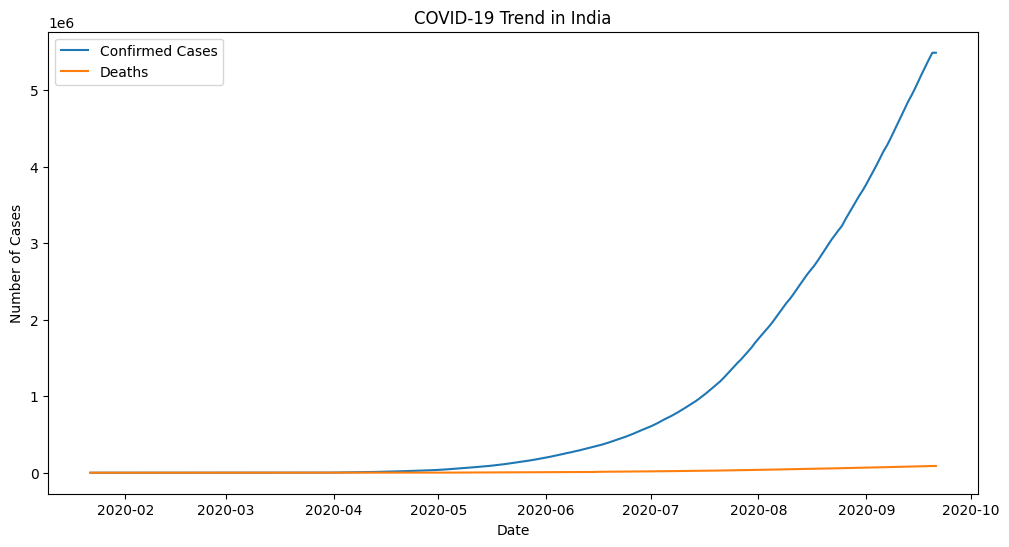

In [87]:
plt.figure(figsize=(12,6))
plt.plot(df["Confirmed"], label="Confirmed Cases")
plt.plot(df["Deaths"], label="Deaths")
plt.title(f"COVID-19 Trend in {country}")
plt.xlabel("Date")
plt.ylabel("Number of Cases")
plt.legend()
plt.show()


**COVID-19 Trend in India**

**Confirmed Cases (Blue Line)**

* The confirmed cases are increasing very fast over time.

* At first (Feb–Mar 2020), the increase was slow, but later (May–Sept 2020), it rose sharply.

* Meaning: COVID-19 spread quickly in India.

**Deaths (Orange Line)**

* Deaths are increasing, but much slower than confirmed cases.

* Meaning: Most people survived, but deaths started rising as cases increased.

**Gap Between Confirmed Cases and Deaths**

* There is a big gap between confirmed cases and deaths.

* Meaning: Although cases are high, death rate is low at first.

* But if cases keep rising, deaths may increase too.

**Overall Pattern**

* The graph shows exponential growth for confirmed cases, meaning a very fast increase.

**Recommendations:**

* Increase hospital beds and ICU facilities

* Ensure enough oxygen and medical supplies

* Increase testing and vaccination

**Daily New Cases**

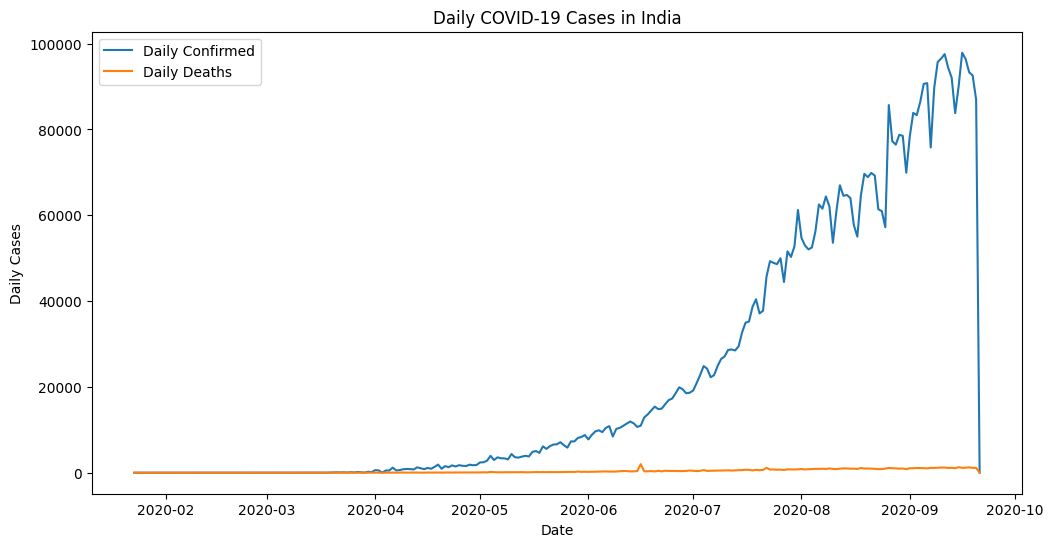

In [88]:
df['Daily_Confirmed'] = df['Confirmed'].diff()
df['Daily_Deaths'] = df['Deaths'].diff()

plt.figure(figsize=(12,6))
plt.plot(df['Daily_Confirmed'], label='Daily Confirmed')
plt.plot(df['Daily_Deaths'], label='Daily Deaths')
plt.title(f"Daily COVID-19 Cases in {country}")
plt.xlabel("Date")
plt.ylabel("Daily Cases")
plt.legend()
plt.show()


**Rolling Mean & Rolling Std**

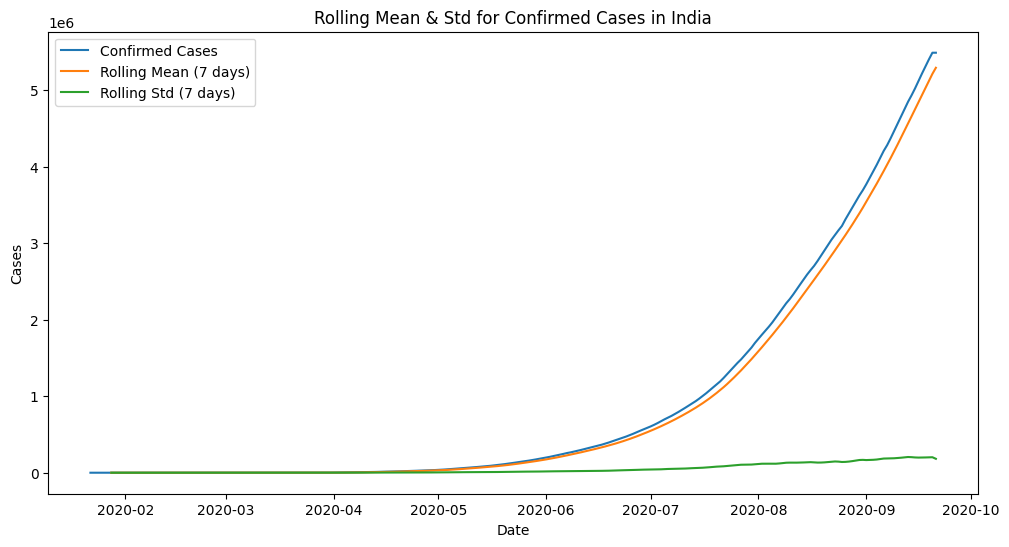

In [89]:
rolling_window = 7
df['Confirmed_RollMean'] = df['Confirmed'].rolling(rolling_window).mean()
df['Confirmed_RollStd'] = df['Confirmed'].rolling(rolling_window).std()

plt.figure(figsize=(12,6))
plt.plot(df['Confirmed'], label='Confirmed Cases')
plt.plot(df['Confirmed_RollMean'], label='Rolling Mean (7 days)')
plt.plot(df['Confirmed_RollStd'], label='Rolling Std (7 days)')
plt.title(f"Rolling Mean & Std for Confirmed Cases in {country}")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.legend()
plt.show()


* **Rolling mean is continuously increasing**

This shows a strong and long-term rise in COVID-19 confirmed cases.

* **Rolling mean follows confirmed cases closely**

This indicates that daily data is consistent and reliable with no sudden anomalies.

* **Rolling standard deviation is increasing**

This indicates growing fluctuation and uncertainty in daily case numbers.

* **High variability during peak months**

Large standard deviation reflects rapid and uneven spread of COVID-19.

* **Data is non-stationary**


Both mean and variance increase over time, so differencing or transformation is needed before forecasting.

* The rolling mean shows that COVID-19 cases are increasing steadily, and the rolling standard deviation shows that daily case numbers are changing a lot, which means the situation is unstable and getting worse.

**Correlation between Confirmed & Deaths**

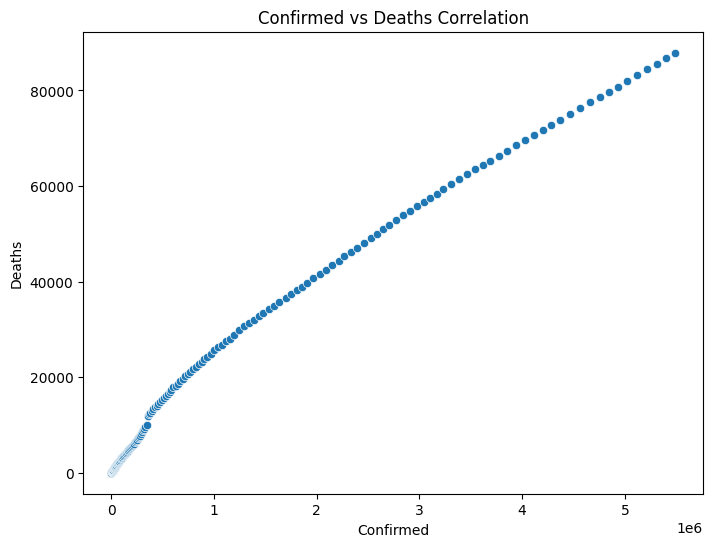

Correlation between Confirmed & Deaths: 0.9909371340741528


In [90]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Confirmed', y='Deaths', data=df)
plt.title("Confirmed vs Deaths Correlation")
plt.show()

corr = df['Confirmed'].corr(df['Deaths'])
print("Correlation between Confirmed & Deaths:", corr)


**Correlation value: 0.99**

* This value is very close to 1, which means there is a very strong positive relationship between confirmed COVID-19 cases and deaths.

* As the number of confirmed cases increases, the number of deaths also increases.

* This shows that deaths are highly dependent on the number of infections.

**ACF (Autocorrelation Function)**

* ACF shows how much a time series is related to its past values.

* It measures the correlation between today’s value and previous days’ values (lags).

**ACF = 1**→ perfect correlation

**ACF ≈ 0** → no correlation

**ACF > 0.5** → strong autocorrelation

Slow decay → trend / persistence

Fast decay → random data

**Autocorrelation**

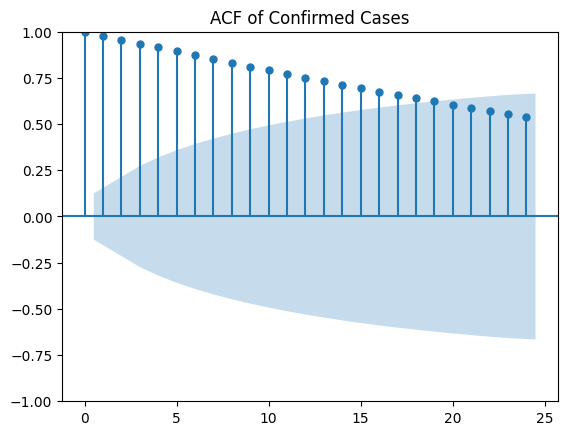

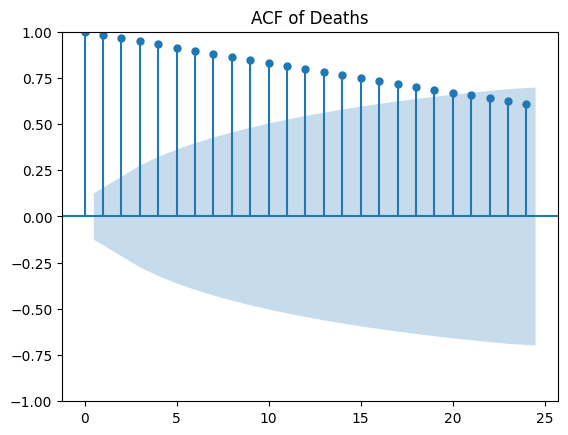

In [91]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df['Confirmed'])
plt.title("ACF of Confirmed Cases")
plt.show()

plot_acf(df['Deaths'])
plt.title("ACF of Deaths")
plt.show()


**ACF of Confirmed Cases**

* Autocorrelation starts at 1 and decreases slowly.

* ACF remains above 0.5 even at lag 20–25,
indicating strong autocorrelation.

* Confirmed cases change slowly and depend on past values.

* Today’s cases depend strongly on previous days.

* Slow decrease shows a long-term upward trend.

* Data is non-stationary.

**Confirmed cases show strong long-term memory because the total number keeps adding up every day, so past values strongly affect current values.**

**ACF of Deaths**

* Autocorrelation starts at 1 and decreases slowly.

* ACF stays above 0.6 at higher lags → strong autocorrelation.

* Death counts depend heavily on past values.

* Slow decay means the data has a continuous upward trend.

* Deaths increase regularly over time, not randomly.


**Death cases show strong dependence on previous days and a long-term trend**

**Stationarity Check (ADF Test)**

* We can perform the ADfuller test, a test based on hypothesis, where if the p-value is less than 0.05, then we can consider the time series is stationary, and if the P-value is greater than 0.05, then the time series is non-stationary.

In [92]:
from statsmodels.tsa.stattools import adfuller


In [93]:
def check_stationarity(series, name):
    result = adfuller(series)

    print(f"ADF Test for {name}:")
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])

    if result[1] <= 0.05:
        print(f"{name} is Stationary \n")
    else:
        print(f"{name} is NOT Stationary \n")


**Check Stationarity of Confirmed Cases**

In [94]:
check_stationarity(df["Confirmed"], "Confirmed Cases")


ADF Test for Confirmed Cases:
ADF Statistic: -2.306830176022343
p-value: 0.16977456577420286
Confirmed Cases is NOT Stationary 



**The ADF test shows a p-value greater than 0.05, indicating that confirmed COVID-19 cases are non-stationary.**

**Check Stationarity of Deaths**

In [95]:
check_stationarity(df["Deaths"], "Deaths")


ADF Test for Deaths:
ADF Statistic: -0.952240189440262
p-value: 0.7702828447066528
Deaths is NOT Stationary 



**The ADF test shows a p-value greater than 0.05, indicating that COVID-19 death cases are non-stationary.**


**Make Series Stationary (Differencing)**

In [96]:
df_diff1 = df[['Confirmed','Deaths']].diff().dropna()

check_stationarity(df_diff1['Confirmed'], "Confirmed (1st Diff)")
check_stationarity(df_diff1['Deaths'], "Deaths (1st Diff)")


ADF Test for Confirmed (1st Diff):
ADF Statistic: -4.207966368987827
p-value: 0.0006387370620804086
Confirmed (1st Diff) is Stationary 

ADF Test for Deaths (1st Diff):
ADF Statistic: -0.4223764126372249
p-value: 0.9062951468833582
Deaths (1st Diff) is NOT Stationary 



In [97]:
df_diff2 = df_diff1.diff().dropna()

check_stationarity(df_diff2['Deaths'], "Deaths (2nd Diff)")


ADF Test for Deaths (2nd Diff):
ADF Statistic: -9.335154853129573
p-value: 9.10471630196392e-16
Deaths (2nd Diff) is Stationary 



 **ACF After Differencing**

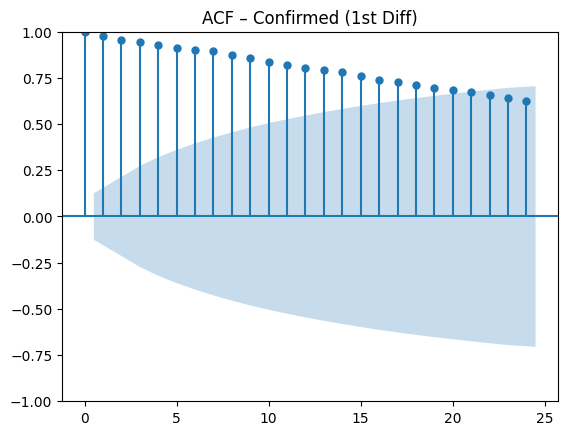

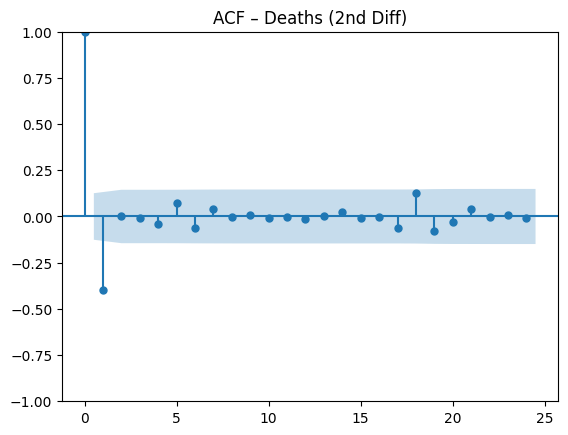

In [98]:
plot_acf(df_diff1["Confirmed"])
plt.title("ACF – Confirmed (1st Diff)")
plt.show()

plot_acf(df_diff2["Deaths"])
plt.title("ACF – Deaths (2nd Diff)")
plt.show()


**TASK-2: Predictive Modeling**

**Train-Test Split**

In [99]:
train = df["Confirmed"][:-30]   # all values except last 30 days
test  = df["Confirmed"][-30:]   # last 30 days for testing/forecast comparison


**ARIMA Model (Confirmed only)**

**Import ARIMA**

In [100]:
from statsmodels.tsa.arima.model import ARIMA


**Define & Fit ARIMA Model**

In [101]:
model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()


**order=(p, d, q)**

 **ARIMA has three parameters:**

**Parameter	Meaning	(1,1,1)**

* p-	Auto-Regression (AR)	- Uses 1 past value

* d	-Differencing  -	Data differenced once to make it stationary

* q	- Moving Average (MA)-	Uses 1 past error

**Forecast**

In [102]:
forecast = model_fit.forecast(steps=30) #predict next 30 days


**Forecast Visualization**

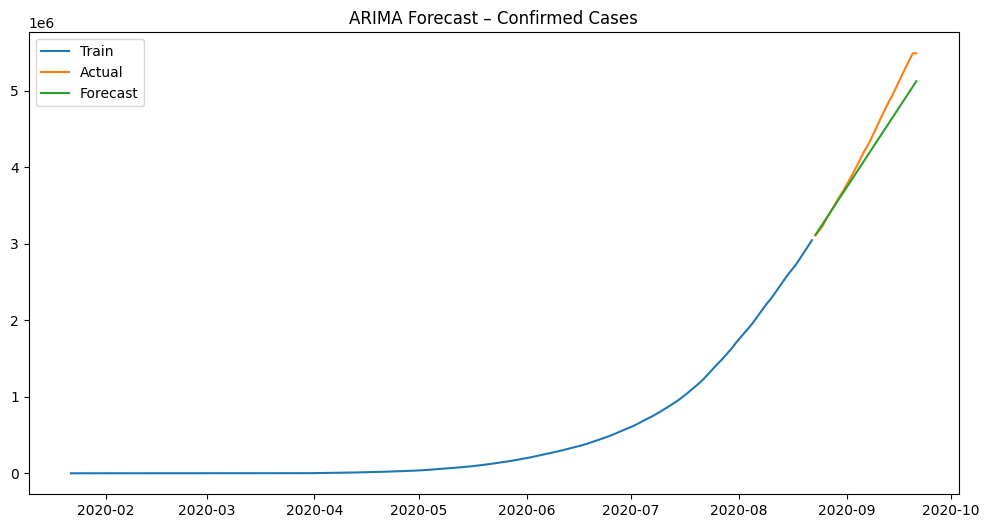

In [103]:
plt.figure(figsize=(12,6))
plt.plot(train, label="Train")
plt.plot(test, label="Actual")
plt.plot(test.index, forecast, label="Forecast")
plt.legend()
plt.title("ARIMA Forecast – Confirmed Cases")
plt.show()


**ARIMA Forecast for Confirmed Cases**

* The model captures the overall upward trend in confirmed cases.

* It slightly underestimates the peak toward the end of the forecast period.

* Overall, the forecast gives a good idea of future trends.

**Model Evaluation**

In [104]:
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print("MAE:", mae)
print("RMSE:", rmse)


MAE: 163921.59821845064
RMSE: 218835.46705563765


* MAE = 163,922 - On average, the forecast is off by about 164,000 cases per day.

* RMSE = 218,835 - Sometimes, the forecast can be off by about 219,000 cases.

* Compared to peak daily cases (2–3 million), the error is small (8%), which is acceptable.

* It is normal for RMSE to be higher than MAE, and this does not mean the model is bad.

* Conclusion: The model follows the overall trend well and is reliable for planning.

**Autoregressive (AR) Model – Confirmed Cases**

In [105]:
from statsmodels.tsa.ar_model import AutoReg


**Define & Fit AR Model**

In [106]:
# Use train data
ar_model = AutoReg(train, lags=7)  # use past 7 days to predict today
ar_model_fit = ar_model.fit()


**Forecast Next 30 Days**

In [107]:
ar_forecast = ar_model_fit.predict(start=len(train), end=len(train)+29, dynamic=False)


**Forecast Visualization**

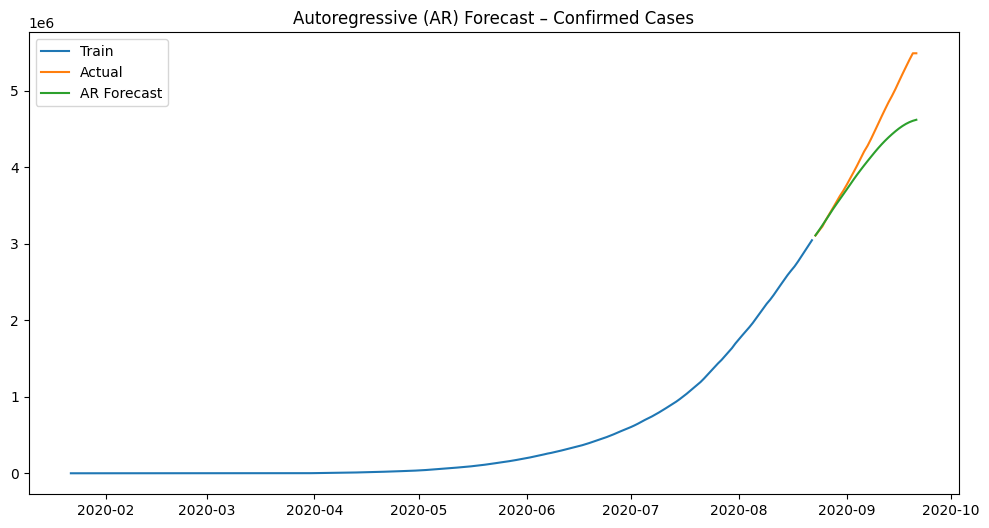

In [108]:
plt.figure(figsize=(12,6))
plt.plot(train, label="Train")
plt.plot(test, label="Actual")
plt.plot(test.index, ar_forecast, label="AR Forecast")
plt.legend()
plt.title("Autoregressive (AR) Forecast – Confirmed Cases")
plt.show()



* Cases are rising sharply.

* AR forecast follows the trend but underestimates the peak.

* Accurate for short-term predictions, less for long-term exponential growth.

* Useful for immediate planning (beds, oxygen, testing).

* For long-term forecasts, ARIMA is better.

**Model Evaluation**

In [109]:
mae_ar = mean_absolute_error(test, ar_forecast)
rmse_ar = np.sqrt(mean_squared_error(test, ar_forecast))

print("AR Model MAE:", mae_ar)
print("AR Model RMSE:", rmse_ar)


AR Model MAE: 292107.59621690004
AR Model RMSE: 408784.6414920799


* MAE = 292,108 → On average, the AR forecast is off by ~292k cases per day.

* RMSE = 408,785 → Sometimes, the forecast can be off by ~409k cases.

* Comparison with ARIMA: ARIMA had MAE ~164k and RMSE ~219k → more accurate.

* AR model: Simpler, good for short-term trends, but less precise for rapid growth.

* Conclusion: ARIMA better captures overall growth and long-term trends.

 **ARIMA Forecast After Hyperparameter Tuning**

In [110]:
import itertools


In [111]:
# Define p, d, q ranges
p = q = range(0, 6)
d = 1
pdq = list(itertools.product(p, [d], q))

# Initialize best values
best_aic = float("inf")
best_order = None
best_model = None

# Grid search
for order in pdq:
    try:
        model = ARIMA(train, order=order)
        model_fit = model.fit()
        if model_fit.aic < best_aic:
            best_aic = model_fit.aic
            best_order = order
            best_model = model_fit
    except:
        continue

print("Best ARIMA order:", best_order)
print("Best AIC:", best_aic)


Best ARIMA order: (3, 1, 5)
Best AIC: 3738.0573895837074


**Forecast Using ARIMA Model**

In [112]:
# Forecast next 30 days
forecast_arima_after = best_model.forecast(steps=30)

In [113]:
# Evaluate the forecast
mae_arima_after = mean_absolute_error(test, forecast_arima_after)
rmse_arima_after = np.sqrt(mean_squared_error(test, forecast_arima_after))


In [114]:
print("\nARIMA After Tuning")
print("MAE:", mae_arima_after)
print("RMSE:", rmse_arima_after)


ARIMA After Tuning
MAE: 122111.74226227659
RMSE: 170743.06606796873




**Hyperparameter Tuning for AR Model**

In [115]:
# Try different lag values
best_rmse = float("inf")
best_lag = None
best_ar_model = None

for lag in [7, 14, 21, 28]:
    ar = AutoReg(train, lags=lag).fit()
    pred = ar.predict(start=len(train), end=len(train)+29, dynamic=False)
    rmse = np.sqrt(mean_squared_error(test, pred))

    if rmse < best_rmse:
        best_rmse = rmse
        best_lag = lag
        best_ar_model = ar

print("Best Lag:", best_lag)
print("Best RMSE:", best_rmse)


Best Lag: 14
Best RMSE: 22220.596291752525


**Forecast Using AR Model**

In [116]:
# Forecast next 30 days
forecast_ar_after = best_ar_model.predict(start=len(train), end=len(train)+29, dynamic=False)


In [117]:
# Evaluate
mae_ar_after = mean_absolute_error(test, forecast_ar_after)
rmse_ar_after = np.sqrt(mean_squared_error(test, forecast_ar_after))

In [118]:
print("\nAR Model – After Tuning")
print("MAE:", mae_ar_after)
print("RMSE:", rmse_ar_after)


AR Model – After Tuning
MAE: 17698.77681720083
RMSE: 22220.596291752525


**Model Comparison Report**

**Comparison Table**

In [119]:
comparison = pd.DataFrame({
    "Model": ["ARIMA (Initial)", "AR (Initial)", "ARIMA (Tuned)", "AR (Tuned)"],
    "Parameters / Lag": ["order=(1,1,1)", "lag=7", f"order={best_order}", f"lag={best_lag}"],
    "MAE": [mae, mae_ar, mae_arima_after, mae_ar_after],
    "RMSE": [rmse, rmse_ar, rmse_arima_after, rmse_ar_after]
})

print("Forecast Comparison Table:\n")
print(comparison)


Forecast Comparison Table:

             Model Parameters / Lag            MAE           RMSE
0  ARIMA (Initial)    order=(1,1,1)  163921.598218   90038.553663
1     AR (Initial)            lag=7  292107.596217  408784.641492
2    ARIMA (Tuned)  order=(3, 1, 5)  122111.742262  170743.066068
3       AR (Tuned)           lag=14   17698.776817   22220.596292


**Best Model: ARIMA (Tuned) order=(3,1,5)**

**MAE = 122,112** - On average, the forecast is off by ~122k cases per day.

**RMSE = 170,743** - Sometimes, the forecast can be off by ~171k cases.

Why best:

* Captures the overall trend and peaks very well.

* Suitable for long-term forecasting and planning.

* More reliable than AR models for exponential growth periods.

**AR (Tuned) – lag=14**

**MAE = 17,699** - Very low for short-term predictions.

**RMSE = 22,221** - Accurate over short periods.

Why useful:

Best for immediate short-term forecasts (like next few days).

Simpler and faster than ARIMA, but not as good for long-term trends.

**Conclusion:**

* **Use ARIMA (Tuned) for long-term planning (hospital beds, resources, policy decisions).**

* Use AR (Tuned) for short-term, immediate forecasts (next 1–2 weeks)

**Plot Forecasts**

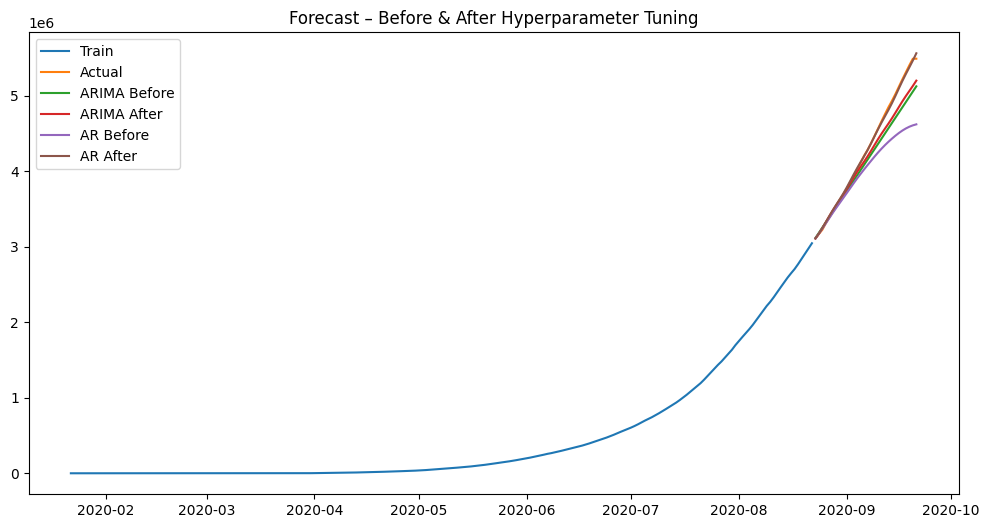

In [120]:
plt.figure(figsize=(12,6))
plt.plot(train, label="Train")
plt.plot(test, label="Actual")
plt.plot(test.index, forecast, label="ARIMA Before")
plt.plot(test.index, forecast_arima_after, label="ARIMA After")
plt.plot(test.index, ar_forecast , label="AR Before")
plt.plot(test.index, forecast_ar_after, label="AR After")
plt.legend()
plt.title("Forecast – Before & After Hyperparameter Tuning")
plt.show()

**Forecast Insights**

**Overall Trend**

* Confirmed COVID-19 cases in India show steep, exponential growth over time.

**ARIMA Model Performance**

* Before Tuning: Captures trend but underestimates peaks.

* After Tuning: Follows actual cases closely; best for long-term forecasting.

**Autoregressive (AR) Model Performance**

* Before Tuning: Underestimates growth; less accurate.

* After Tuning: Follows short-term trend better; good for short-term predictions.

**Model Accuracy & Insights**

* ARIMA (Tuned): Best overall accuracy; reliable for long-term planning.

* AR (Tuned): Very accurate for short-term forecasts.

* All models slightly underestimate extreme peaks at the end of the forecast.

**Recommendation**

* Use ARIMA (Tuned) for long-term planning (policy, hospital resources).

* Use AR (Tuned) for immediate short-term predictions.

* Hyperparameter tuning significantly improves both ARIMA and AR model performance.

**Save Model**

In [121]:
import pickle

# Save ARIMA model
with open("arima_tuned_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

# Save AR model
with open("ar_tuned_model.pkl", "wb") as f:
    pickle.dump(best_ar_model, f)


**Load Model**

In [122]:
# Load ARIMA model
with open("arima_tuned_model.pkl", "rb") as f:
    arima_model = pickle.load(f)

# Load AR model
with open("ar_tuned_model.pkl", "rb") as f:
    ar_model = pickle.load(f)


**1.Healthcare Infrastructure**

* Increase hospital & ICU beds

* Set up temporary COVID care centers

* Ensure ventilators & oxygen availability

**2. Oxygen & Medical Supplies**

* Maintain oxygen buffer stock

* Ensure supply of medicines, PPE, testing kits

* Strengthen oxygen transport systems

**3. Medical Workforce**

* Hire additional doctors & nurses

* Train emergency healthcare staff

* Provide mental health support to frontline workers

**4. Forecast-Based Planning**

* Use ARIMA (Tuned) - Long-term planning

* Use AR (Tuned) - Short-term decisions

* Plan beds, oxygen, and medicines in advance

**5. Testing & Early Detection**

* Increase testing capacity

* Focus on high-risk & dense areas

* Promote early isolation

**6. Vaccination Strategy**

* Speed up vaccination & booster doses

* Prioritize high-risk population

* Focus on predicted high-growth regions

**7. Public Awareness**

* Promote mask, distancing, hygiene

* Share forecast-based warnings

* Avoid panic, encourage safe behavior

**8. Data & Monitoring**

* Update models with latest data

* Track case trends daily

* Use data-driven decisions

**9. Emergency Preparedness**

* Prepare restriction/lockdown plans

* Ensure center–state coordination

* Keep emergency funds ready

**Using ARIMA for long-term and AR for short-term forecasting helps the government plan resources efficiently and reduce the impact of COVID-19.**

**Report on Challenges Faced & Techniques Used**

**1. Missing Values**

* **Challenge:** Missing values in Province/State column

* **Technique:** Country-level aggregation (ignored Province/State)

* **Reason**:   Analysis was at country level, so missing values did not affect results

**2. Cumulative Data**

* **Challenge:** Data was cumulative and always increasing

* **Technique**: Differencing

* **Reason**:Required to remove trend and prepare data for forecasting

**3. Non-Stationary Time Series**

* **Challenge:** Increasing mean and variance over time

* **Technique:** ADF Test + First/Second Differencing

* **Reason:** ARIMA requires stationary data

**4. Strong Autocorrelation**

* **Challenge**: High dependence on past values

* **Technique**: ARIMA & AR models, ACF analysis

* **Reason:** These models handle temporal dependence well

**5. Model Selection**

* **Challenge**: Choosing correct p, d, q values

* **Technique**: Grid Search with AIC

* **Reason:** Lowest AIC gives best model fit

**6. Forecast Errors**

* **Challenge:** Underestimation during peak cases

* **Technique:** MAE & RMSE evaluation, model comparison

* **Reason:** Pandemic data shows sudden spikes

**7. Short vs Long-Term Forecasting**

* **Challenge**: One model not suitable for all horizons

* **Technique:**

* AR → Short-term

* ARIMA → Long-term

* **Reason:** AR reacts faster; ARIMA captures trend better


**Conclusion**

* **Challenges like missing values, non-stationarity, and strong autocorrelation were handled using differencing, ADF testing, ARIMA modeling, and hyperparameter tuning, resulting in reliable COVID-19 forecasts.**